In [1]:
import numpy as np
import cv2
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
import os
import pandas as pd

In [2]:
# Define paths for the Sentinel-2 bands
# This assumes we have access to the individual band files, not just the TCI composite
base_path = "../src/trimmed-sentinel-2-data/"
red_band_path = os.path.join(base_path, "trimmed_B04.tif")  # Band 4 (Red)
nir_band_path = os.path.join(base_path, "trimmed_B08.tif")   # Band 8 (NIR)
tci_path = os.path.join(base_path, "trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif")      # True Color Image


In [3]:
# Load the TCI image for visualization
with rasterio.open(tci_path) as src:
    tci_image = src.read()
    height, width = tci_image.shape[1], tci_image.shape[2]
    transform = src.transform
    crs = src.crs

# Load the Red and NIR bands for NDVI calculation
with rasterio.open(red_band_path) as src:
    red_band = src.read(1).astype(float)

with rasterio.open(nir_band_path) as src:
    nir_band = src.read(1).astype(float)

In [4]:
# Calculate NDVI
# To prevent division by zero, add a small epsilon
eps = 1e-8
ndvi = (nir_band - red_band) / (nir_band + red_band + eps)

# Create NDVI mask for crop areas (NDVI >= 0.4)
ndvi_mask = (ndvi >= 0.4).astype(np.uint8)#

# Prepare TCI image for processing
img = np.transpose(tci_image, (1, 2, 0))
img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

In [5]:
# Create grayscale image
gray = cv2.cvtColor(img_8bit, cv2.COLOR_RGB2GRAY)

# Apply bilateral filter
filtered = cv2.bilateralFilter(gray, 5, 75, 75)

# Apply Canny edge detection
edges = cv2.Canny(filtered, 40, 110)

# Apply morphological operations to close small gaps in edges
kernel = np.ones((2, 2), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

In [6]:
# Find contours with hierarchy information
contours, hierarchy = cv2.findContours(closed_edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Get hierarchy in the right format
if hierarchy is not None:
    hierarchy = hierarchy[0]  # OpenCV returns hierarchy as a nested structure
else:
    # If no hierarchy found, just process all contours
    hierarchy = np.zeros((len(contours), 4), dtype=np.int32) - 1

In [7]:
# Define min and max area for valid contours
min_area = 75
max_area = height * width * 0.12

# Create a set to store indices of outer contours that contain other valid contours
outer_contours_to_ignore = set()

# Identify valid contours by area
valid_contours = []
valid_indices = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if min_area < area < max_area:
        valid_contours.append(cnt)
        valid_indices.append(i)

# For each valid contour, check if it has a parent
# If the parent is also valid, mark the parent to be ignored
for i, idx in enumerate(valid_indices):
    # Check if this contour has a parent
    parent_idx = hierarchy[idx][3]
    # If parent exists and is also a valid contour, mark the parent to be ignored
    if parent_idx != -1 and parent_idx in valid_indices:
        outer_contours_to_ignore.add(parent_idx)


In [8]:
# Create segmentation map with integer IDs for each field
segmentation = np.zeros((height, width), dtype=np.int32)
field_id = 1  # Start field IDs at 1 (0 is background)


# Process each valid contour that's not marked to be ignored
for i, idx in enumerate(valid_indices):
    if idx not in outer_contours_to_ignore:
        cnt = contours[idx]
        
        # Apply additional road filtering
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter <= 0:
            continue
        
        rect = cv2.minAreaRect(cnt)
        box_width, box_height = rect[1]
        if min(box_width, box_height) <= 0:
            continue
        
        # Aspect ratio of the bounding rectangle
        aspect_ratio = max(box_width, box_height) / min(box_width, box_height)
        
        # Minimum bounding rectangle area
        rect_area = box_width * box_height
        
        # Rectangularity (how well the contour fills its bounding rectangle)
        rectangularity = area / rect_area if rect_area > 0 else 0
        
        # Filter out obvious roads - very rectangular and nearly square
        if not (rectangularity > 0.9 and 0.9 < aspect_ratio < 1.1):
            # Create a mask for this contour
            contour_mask = np.zeros((height, width), dtype=np.uint8)
            cv2.drawContours(contour_mask, [cnt], 0, 1, -1)
            
            # Check if this contour has enough crop area (NDVI >= 0.4)
            # Multiply contour mask with NDVI mask to get crop area within contour
            crop_area_in_contour = np.logical_and(contour_mask, ndvi_mask)
            
            # Calculate percentage of crop area within the contour
            contour_pixels = np.sum(contour_mask)
            crop_pixels = np.sum(crop_area_in_contour)
            crop_percentage = crop_pixels / contour_pixels if contour_pixels > 0 else 0
            
            # Only add contours that have significant crop area (at least 50%)
            if crop_percentage >= 0.5:
                # Fill the contour with the field_id in the segmentation map
                cv2.drawContours(segmentation, [cnt], 0, field_id, -1)
                field_id += 1

# Apply the NDVI mask to the final segmentation
# This ensures we only include areas with NDVI >= 0.4 in our final result
segmentation_with_ndvi = segmentation * ndvi_mask

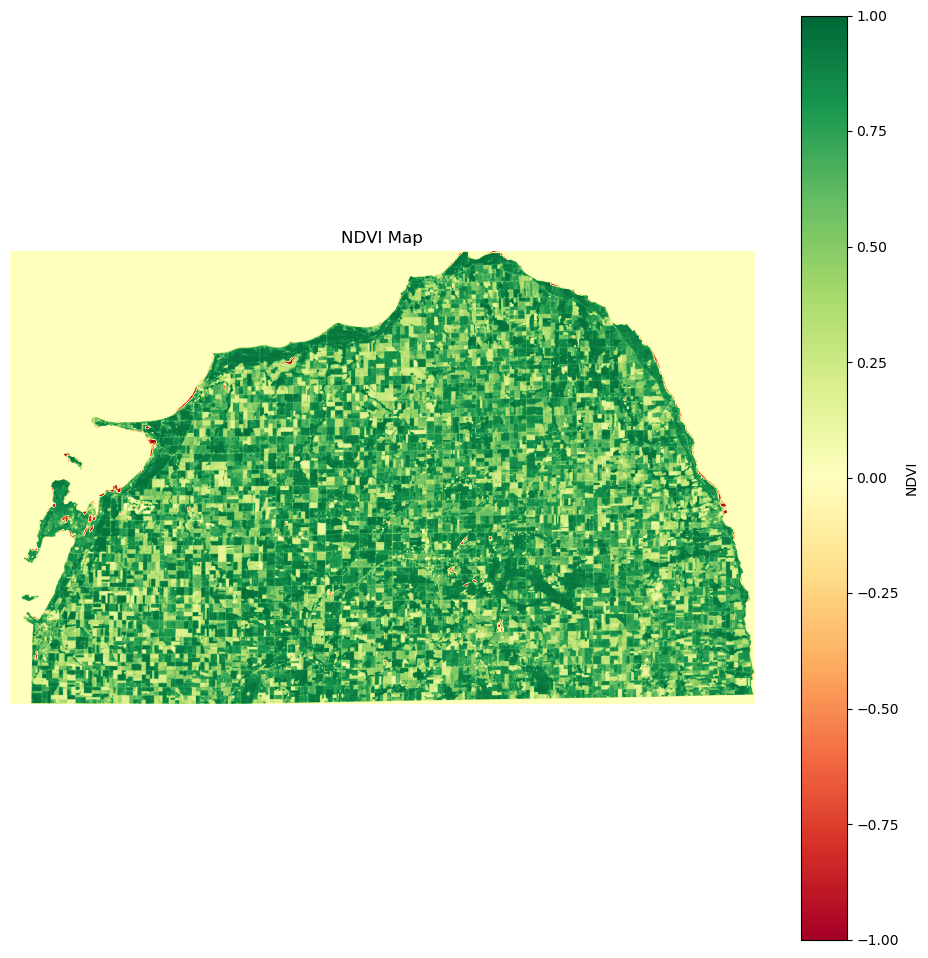

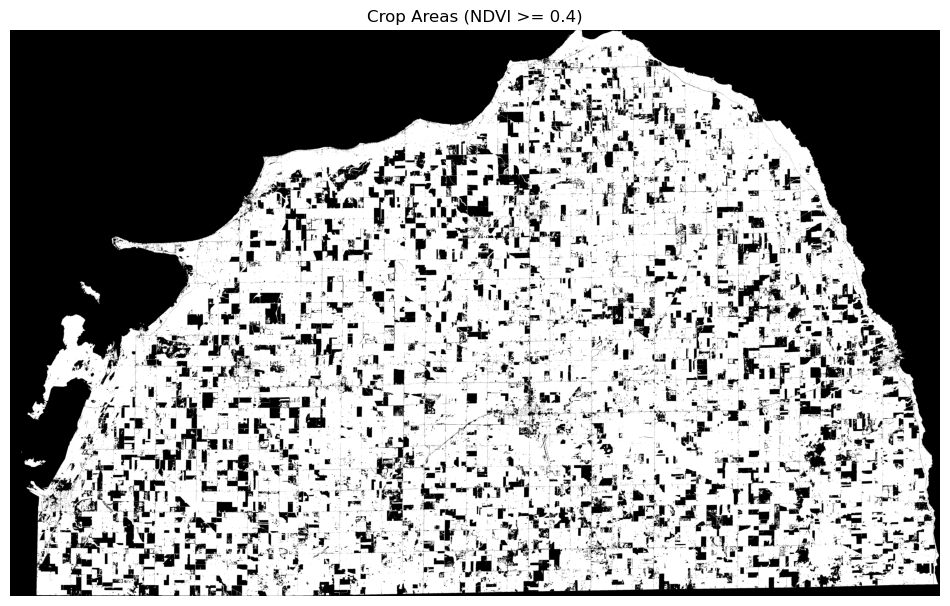

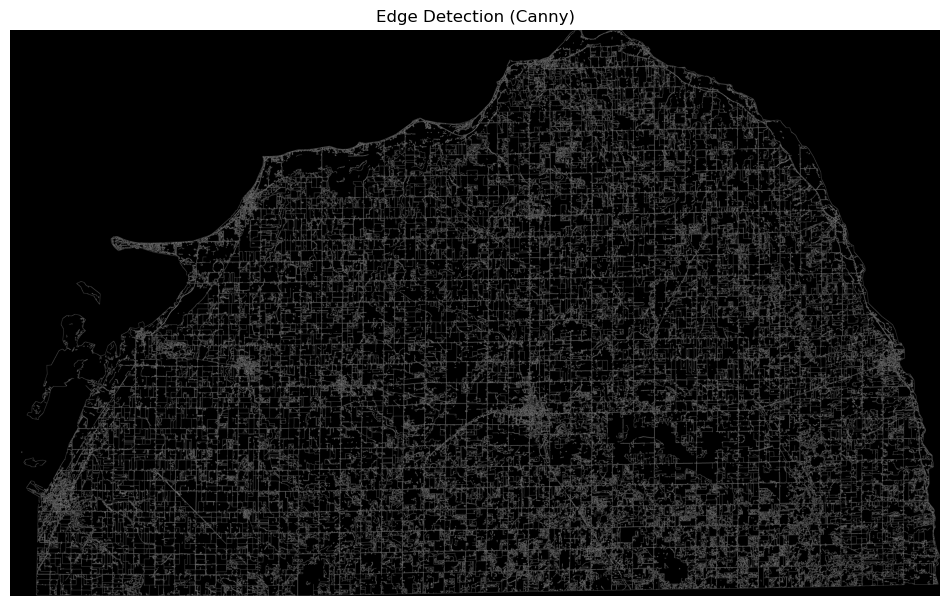

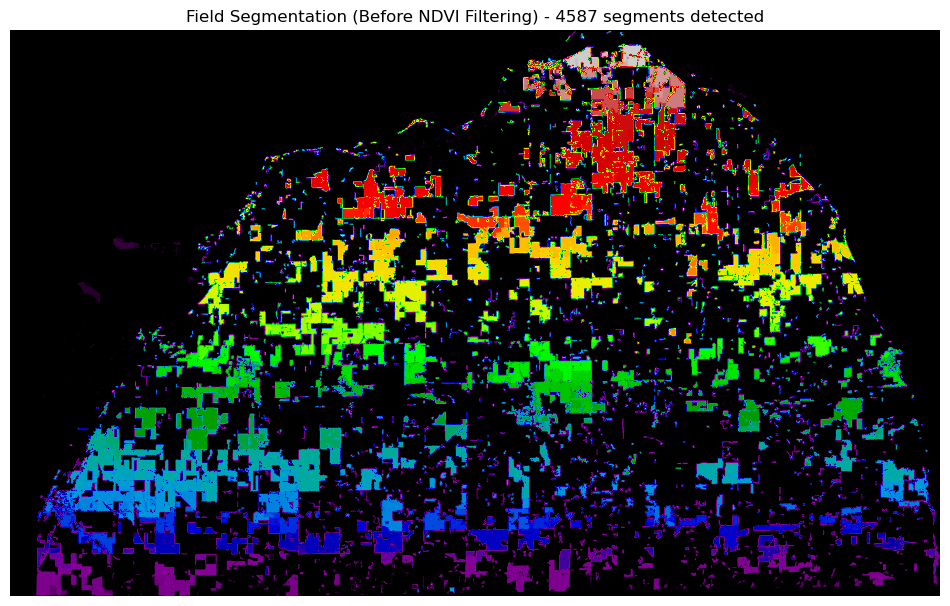

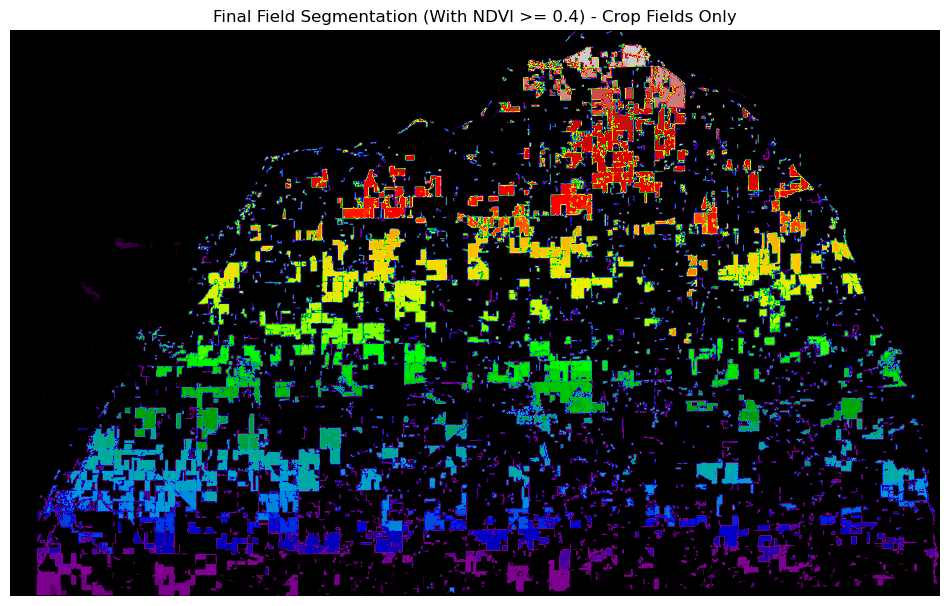

In [9]:
# 1. NDVI map
plt.figure(figsize=(12, 12))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title("NDVI Map")
plt.axis('off')
plt.show()

# 2. Crop mask (NDVI >= 0.4)
plt.figure(figsize=(12, 12))
plt.imshow(ndvi_mask, cmap='gray')
plt.title("Crop Areas (NDVI >= 0.4)")
plt.axis('off')
plt.show()

# 3. Edge detection
plt.figure(figsize=(12, 12))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis('off')
plt.show()

# 4. Original segmentation (before NDVI filtering)
plt.figure(figsize=(12, 12))
plt.imshow(segmentation, cmap='nipy_spectral')
plt.title(f"Field Segmentation (Before NDVI Filtering) - {field_id-1} segments detected")
plt.axis('off')
plt.show()

# 5. Final segmentation (with NDVI filtering)
plt.figure(figsize=(12, 12))
plt.imshow(segmentation_with_ndvi, cmap='nipy_spectral')
plt.title(f"Final Field Segmentation (With NDVI >= 0.4) - Crop Fields Only")
plt.axis('off')
plt.show()

In [10]:
# Save the final segmentation directly as a GeoTIFF
with rasterio.open("ndvi_filtered_segmentation.tif", 'w',
                  driver='GTiff',
                  height=height,
                  width=width,
                  count=1,
                  dtype=rasterio.uint8,
                  crs=crs,
                  transform=transform) as dst:
    dst.write(segmentation_with_ndvi, 1)